# Pré-processamento — House Prices (Ames, Iowa)

Este notebook realiza o **pré-processamento completo dos dados**, preparando-os para a etapa de modelagem preditiva. Cada decisão é tomada com base nos achados da Análise Exploratória de Dados (EDA): a transformação logarítmica do alvo, a remoção de outliers, o tratamento diferenciado de valores ausentes e a codificação ordinal das variáveis de qualidade.

O notebook segue um princípio central: **investigar antes de agir**. Cada tratamento de valor ausente é precedido por uma inspeção que confirma a hipótese, com todo o raciocínio documentado passo a passo — e nenhuma estatística é ajustada (`fit`) fora do conjunto de treino, evitando vazamento de dados (*data leakage*).

## Um problema pouco óbvio: inconsistências dentro de grupos de colunas relacionadas

Ao investigar a fundo os dados ausentes, encontramos um padrão sutil: em grupos de colunas relacionadas (`Garage*`, `Bsmt*`, `MasVnr*`, `Pool*`, `MiscFeature`/`MiscVal`), normalmente **todas as colunas do grupo ficam ausentes juntas** quando a casa simplesmente não tem aquele recurso (ex.: sem garagem → `GarageType`, `GarageArea`, `GarageQual`... todos `NaN`). Mas existem **casos raros em que só uma parte do grupo está ausente**, enquanto outras colunas do mesmo grupo têm valor preenchido — um sinal claro de que ali **existe o recurso**, e o dado está genuinamente perdido (não é ausência estrutural).

Preencher esses casos com `"None"` / `0` introduziria um erro factual no dataset: diria "esta casa não tem garagem" para uma casa que **o próprio dataset afirma ter uma garagem** (`GarageType = "Detchd"`). Encontramos e corrigimos **5 grupos** com esse problema:

| Grupo | Casos encontrados | Evidência de que o recurso existe |
|---|---|---|
| Garagem | 2 casas | `GarageType = "Detchd"` preenchido, mas `GarageYrBlt`/`GarageFinish`/`GarageQual`/`GarageCond` (e, em 1 caso, também `GarageCars`/`GarageArea`) ausentes |
| Porão | 9 casas (distribuídas em `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType2`) | `TotalBsmtSF > 0` (porão tem área!), mas uma coluna categórica específica do porão está ausente |
| Revestimento de alvenaria | 8 casas | `MasVnrArea > 0` (há área de revestimento!), mas `MasVnrType` está ausente |
| Piscina | 3 casas | `PoolArea > 0` (a piscina existe!), mas `PoolQC` está ausente |
| Recurso diverso (`MiscFeature`) | 1 casa | `MiscVal = 17.000` (valor de um recurso especial!), mas `MiscFeature` está ausente |

Essas inconsistências são um traço conhecido deste dataset. Este notebook as trata explicitamente, **antes** de qualquer preenchimento estrutural genérico — do contrário, o preenchimento genérico as classificaria incorretamente como "sem o recurso".


## Roteiro

1. Configuração do ambiente e carregamento dos dados
2. Remoção de outliers (conclusão da EDA)
3. Separação do alvo, transformação logarítmica e unificação treino/teste
4. Ajuste de tipos — antes de qualquer codificação
5. Diagnóstico geral de valores ausentes
6. Casos inconsistentes: dado genuinamente perdido dentro de um grupo estrutural
7. Tratamento das ausências estruturais (recurso realmente inexistente)
8. Classificação das variáveis categóricas em ordinais vs. nominais
9. Matriz auxiliar para a imputação por KNN
10. Imputação das ausências residuais (moda + KNN, sem vazamento de dados)
11. Validação da qualidade da imputação
12. Montagem do dataset final e checagens de sanidade
13. Exportação dos dados processados


## 1. Configuração do ambiente e carregamento dos dados

In [1]:
import pandas as pd    # pandas: biblioteca de manipulação de tabelas (DataFrames)
import numpy as np     # numpy: biblioteca de computação numérica (arrays, np.nan, np.number)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42


In [2]:
# pd.read_csv() lê um arquivo CSV do disco e devolve um DataFrame (tabela)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Treino:', train.shape)
print('Teste :', test.shape)
train.head()


Treino: (1460, 81)
Teste : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Remoção de outliers

A EDA identificou duas casas com `GrLivArea` acima de 4.000 pés² vendidas por menos de US\$300 mil — muito abaixo do que a relação entre área e preço sugeriria para o restante do dataset. Esse padrão é amplamente reconhecido na literatura sobre este dataset e recomenda-se removê-las **antes de qualquer outra etapa**, já que outliers desse tipo distorceriam tanto a imputação (o KNN passaria a considerar essas casas "parecidas" com outras que não são) quanto o treinamento futuro do modelo.

Essa remoção só pode ser feita no conjunto de **treino** — o teste não tem `SalePrice`, então não há como aplicar esse critério nele.

In [3]:
# Inspecionar antes de remover, para confirmar a hipótese
mascara_outliers = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)

print('Outliers identificados:')
display(train.loc[mascara_outliers, ['Id', 'GrLivArea', 'SalePrice']])

n_antes = train.shape[0]
train = train.drop(train[mascara_outliers].index).reset_index(drop=True)

print(f'\nLinhas antes: {n_antes} | Linhas depois: {train.shape[0]} | Removidas: {n_antes - train.shape[0]}')


Outliers identificados:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000



Linhas antes: 1460 | Linhas depois: 1458 | Removidas: 2


## 3. Separação do alvo, transformação logarítmica e unificação treino/teste

A métrica oficial da competição é o RMSE calculado sobre `log(SalePrice)`, e a EDA mostrou que `log1p(SalePrice)` tem distribuição muito mais próxima da normal do que `SalePrice` em escala original. Por isso, já separamos e transformamos o alvo aqui — ele será usado dessa forma na modelagem, e revertido com `expm1` apenas na hora de gerar as previsões finais.

Em seguida, unimos treino e teste em um único DataFrame (`dados`) para garantir que toda a limpeza estrutural (ajuste de tipos, preenchimento de "None"/0) seja **idêntica** nos dois conjuntos. Isso não envolve nenhuma estatística calculada a partir dos dados — não é um `fit` de nada, então não há vazamento de informação nessa etapa. As transformações que aprendem estatísticas dos dados (padronização e KNN, mais adiante) serão ajustadas **somente no treino**, como veremos na Seção 10.

In [4]:
# .copy() cria uma cópia independente, evitando que mudanças futuras em y afetem train
y = np.log1p(train['SalePrice'].copy())

# .drop(columns=[...]) devolve um NOVO DataFrame sem a coluna indicada (o original não é alterado)
X_train = train.drop(columns=['SalePrice'])
X_test = test.copy()

# Guardar os IDs do teste para a submissão final no Kaggle
test_ids = X_test['Id'].copy()

# pd.concat empilha os DataFrames:
#   axis=0            -> empilha na vertical (linhas embaixo de linhas)
#   ignore_index=True -> descarta os índices antigos e cria um novo (0..N-1),
#                        evitando índices duplicados entre treino e teste
dados = pd.concat([X_train, X_test], axis=0, ignore_index=True)

# O Id é apenas um identificador: não carrega informação sobre o preço
dados = dados.drop(columns=['Id'])

# n_train guarda quantas linhas o treino tinha originalmente — é o índice de corte
# que usaremos sempre que precisarmos separar dados de volta em treino/teste
ntrain = len(X_train)

print('Linhas de treino (ntrain):', ntrain)
print('Linhas de teste           :', dados.shape[0] - ntrain)
print('Shape de dados (unificado):', dados.shape)


Linhas de treino (ntrain): 1458
Linhas de teste           : 1459
Shape de dados (unificado): (2917, 79)


## 4. Ajuste de tipos — antes de qualquer codificação

`MSSubClass` é um código numérico (20, 60, 120...) que na verdade representa uma **categoria** de tipo de construção (ver `data_description.txt`), não uma escala contínua — não faz sentido dizer que o tipo "120" é "maior" que o tipo "60". `MoSold` e `YrSold` também são melhor tratados como categorias neste contexto.

É essencial fazer essa conversão **agora**, antes de montar qualquer matriz para o KNN (Seção 9) — se fosse feita depois, essas variáveis participariam do cálculo de distância como se fossem numéricas contínuas, distorcendo a noção de "casas parecidas" que o KNN usa para imputar.

In [5]:
colunas_para_texto = ['MSSubClass', 'MoSold', 'YrSold']

for coluna in colunas_para_texto:
    dados[coluna] = dados[coluna].astype(str)

print('Tipos após conversão:')
print(dados[colunas_para_texto].dtypes)


Tipos após conversão:
MSSubClass    str
MoSold        str
YrSold        str
dtype: object


## 5. Diagnóstico geral de valores ausentes

Antes de decidir qualquer estratégia, olhamos o panorama completo: quais colunas têm ausências, e em que volume — tanto entre as numéricas quanto entre as categóricas, essenciais neste dataset.

In [6]:
# Encadeamento de métodos (lido de cima para baixo):
#   .isnull() -> DataFrame de True/False (True onde é NaN)
#   .sum()    -> soma por coluna (True conta como 1) = quantidade de faltantes em cada coluna
ausentes = dados.isnull().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

pd.DataFrame({
    'n_ausentes': ausentes,
    'percentual (%)': (ausentes / len(dados) * 100).round(2),
    'tipo': dados[ausentes.index].dtypes.astype(str)
})


,n_ausentes,percentual (%),tipo
PoolQC,2908,99.69,str
MiscFeature,2812,96.40,str
Alley,2719,93.21,str
Fence,2346,80.43,str
MasVnrType,1766,60.54,str
FireplaceQu,1420,48.68,str
LotFrontage,486,16.66,float64
GarageQual,159,5.45,str
GarageYrBlt,159,5.45,float64
GarageCond,159,5.45,str


A esmagadora maioria dessas colunas pertence a grupos de recurso opcional (`Pool*`, `Garage*`, `Bsmt*`, `Fence`, `Alley`, `FireplaceQu`, `MiscFeature`) — onde `NaN` normalmente significa **"a casa não tem esse recurso"**, e não um dado perdido. Mas, como vimos na introdução, existem exceções dentro desses grupos, e é isso que investigamos na próxima seção **antes** de aplicar qualquer preenchimento genérico.

## 6. Casos inconsistentes: dado genuinamente perdido dentro de um grupo estrutural

### 6.1 Grupo da garagem

Temos duas colunas "âncora" (`GarageType` e `GarageCars`/`GarageArea`, todas relacionadas). Quando `GarageType` está preenchido (ou seja, **a casa tem garagem**), as demais colunas de garagem não deveriam estar ausentes — mas encontramos casos em que estão.

In [7]:
# INSPEÇÃO: casas onde GarageType está preenchido (há garagem) mas outros dados de garagem faltam
mascara_garagem_inconsistente = dados['GarageType'].notnull() & dados['GarageYrBlt'].isnull()

print(f'{mascara_garagem_inconsistente.sum()} casa(s) com GarageType preenchido mas dados de garagem ausentes:')
dados.loc[
    mascara_garagem_inconsistente,
    ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageCars', 'GarageArea']
]


2 casa(s) com GarageType preenchido mas dados de garagem ausentes:


,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,GarageCars,GarageArea
2124,Detchd,NaN,NaN,NaN,NaN,1.0,360.0
2574,Detchd,NaN,NaN,NaN,NaN,NaN,NaN


Ambas as casas têm `GarageType = "Detchd"` (garagem separada da casa) — ou seja, **a garagem existe**, mas seus atributos não foram registrados. Preenchê-los com `"None"`/`0` (como se não houvesse garagem) contradiria a própria informação de `GarageType`. A estratégia mais coerente é estimar esses valores a partir de garagens **do mesmo tipo** (`Detchd`), usando o **treino** como referência (mediana para as numéricas, moda para as categóricas).

In [8]:
# Referência: garagens do tipo "Detchd" observadas no TREINO
referencia_detchd = dados.iloc[:ntrain].query('GarageType == "Detchd"')

mediana_garage_cars = referencia_detchd['GarageCars'].median()
mediana_garage_area = referencia_detchd['GarageArea'].median()
mediana_garage_ano = referencia_detchd['GarageYrBlt'].median()
moda_garage_finish = referencia_detchd['GarageFinish'].mode()[0]
moda_garage_qual = referencia_detchd['GarageQual'].mode()[0]
moda_garage_cond = referencia_detchd['GarageCond'].mode()[0]

print('Valores de referência (garagens Detchd do treino):')
print(f'  GarageCars   -> mediana = {mediana_garage_cars}')
print(f'  GarageArea   -> mediana = {mediana_garage_area}')
print(f'  GarageYrBlt  -> mediana = {mediana_garage_ano}')
print(f'  GarageFinish -> moda    = {moda_garage_finish}')
print(f'  GarageQual   -> moda    = {moda_garage_qual}')
print(f'  GarageCond   -> moda    = {moda_garage_cond}')

# Atribuição via .loc[máscara, coluna] = valor: escreve SOMENTE nas linhas ainda ausentes,
# preservando qualquer valor que a casa já tivesse (caso 1 das duas tenha GarageCars preenchido, por exemplo)
mascara_final = mascara_garagem_inconsistente  # mesma máscara da inspeção acima
for coluna, valor in [
    ('GarageCars', mediana_garage_cars), ('GarageArea', mediana_garage_area),
    ('GarageYrBlt', mediana_garage_ano), ('GarageFinish', moda_garage_finish),
    ('GarageQual', moda_garage_qual), ('GarageCond', moda_garage_cond),
]:
    ainda_ausente = mascara_final & dados[coluna].isnull()
    dados.loc[ainda_ausente, coluna] = valor

print('\nApós a correção:')
dados.loc[
    mascara_garagem_inconsistente,
    ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageCars', 'GarageArea']
]


Valores de referência (garagens Detchd do treino):
  GarageCars   -> mediana = 2.0
  GarageArea   -> mediana = 400.0
  GarageYrBlt  -> mediana = 1965.0
  GarageFinish -> moda    = Unf
  GarageQual   -> moda    = TA
  GarageCond   -> moda    = TA

Após a correção:


,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,GarageCars,GarageArea
2124,Detchd,1965.0,Unf,TA,TA,1.0,360.0
2574,Detchd,1965.0,Unf,TA,TA,2.0,400.0


### 6.2 Grupo do porão

Mesmo raciocínio: usamos `TotalBsmtSF > 0` (o porão tem área registrada, logo existe) como âncora para identificar linhas onde alguma coluna categórica do porão ficou ausente por engano, e não por falta do recurso.

In [9]:
colunas_categoricas_porao = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
tem_porao = dados['TotalBsmtSF'].fillna(0) > 0

for coluna in colunas_categoricas_porao:
    mascara_inconsistente = tem_porao & dados[coluna].isnull()
    n_casos = mascara_inconsistente.sum()
    if n_casos > 0:
        print(f'{coluna}: {n_casos} caso(s) com porão existente mas {coluna} ausente')
        display(dados.loc[mascara_inconsistente, ['TotalBsmtSF'] + colunas_categoricas_porao])


BsmtQual: 2 caso(s) com porão existente mas BsmtQual ausente


,TotalBsmtSF,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
2215,173.0,NaN,Fa,No,Unf,Unf
2216,356.0,NaN,TA,No,Unf,Unf


BsmtCond: 3 caso(s) com porão existente mas BsmtCond ausente


,TotalBsmtSF,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
2038,1426.0,Gd,NaN,Mn,GLQ,Rec
2183,1127.0,TA,NaN,No,BLQ,Unf
2522,995.0,TA,NaN,Av,ALQ,Unf


BsmtExposure: 3 caso(s) com porão existente mas BsmtExposure ausente


,TotalBsmtSF,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
947,936.0,Gd,TA,NaN,Unf,Unf
1485,1595.0,Gd,TA,NaN,Unf,Unf
2346,725.0,Gd,TA,NaN,Unf,Unf


BsmtFinType2: 1 caso(s) com porão existente mas BsmtFinType2 ausente


,TotalBsmtSF,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
332,3206.0,Gd,TA,No,GLQ,NaN


In [10]:
# Correção: preencher cada coluna com a MODA calculada apenas entre casas do TREINO que têm porão
for coluna in colunas_categoricas_porao:
    mascara_inconsistente = tem_porao & dados[coluna].isnull()
    if mascara_inconsistente.sum() == 0:
        continue

    referencia_treino = dados.iloc[:ntrain]
    tem_porao_treino = referencia_treino['TotalBsmtSF'].fillna(0) > 0
    moda_treino = referencia_treino.loc[tem_porao_treino, coluna].mode()[0]

    dados.loc[mascara_inconsistente, coluna] = moda_treino
    print(f'{coluna}: {mascara_inconsistente.sum()} caso(s) preenchido(s) com a moda do treino ("{moda_treino}")')

# Verificação: não deve sobrar nenhum caso de porão existente com coluna categórica ausente
restantes = sum((tem_porao & dados[c].isnull()).sum() for c in colunas_categoricas_porao)
print(f'\nCasos inconsistentes restantes no grupo do porão: {restantes}')


BsmtQual: 2 caso(s) preenchido(s) com a moda do treino ("TA")


BsmtCond: 3 caso(s) preenchido(s) com a moda do treino ("TA")
BsmtExposure: 3 caso(s) preenchido(s) com a moda do treino ("No")
BsmtFinType2: 1 caso(s) preenchido(s) com a moda do treino ("Unf")

Casos inconsistentes restantes no grupo do porão: 0


### 6.3 Grupo de revestimento de alvenaria (`MasVnr`)

Mesmo raciocínio, agora com `MasVnrArea > 0` como âncora: se há área de revestimento registrada, o revestimento existe, então `MasVnrType` ausente é dado perdido, não "sem revestimento".

In [11]:
# INSPEÇÃO: área de revestimento > 0 mas o tipo está ausente
mascara_masvnr_inconsistente = dados['MasVnrType'].isnull() & (dados['MasVnrArea'] > 0)

print(f'{mascara_masvnr_inconsistente.sum()} casa(s) com MasVnrArea > 0 mas MasVnrType ausente:')
dados.loc[mascara_masvnr_inconsistente, ['MasVnrType', 'MasVnrArea']]


8 casa(s) com MasVnrArea > 0 mas MasVnrType ausente:


,MasVnrType,MasVnrArea
623,NaN,288.0
772,NaN,1.0
1229,NaN,1.0
1298,NaN,344.0
1332,NaN,312.0
1667,NaN,285.0
2450,NaN,1.0
2608,NaN,198.0


In [12]:
# Correção: preencher com a moda dos tipos de revestimento REALMENTE existentes no treino
# (excluindo "None", que representaria "sem revestimento" — o oposto do que sabemos ser verdade aqui)
referencia_treino = dados.iloc[:ntrain]
tem_revestimento = referencia_treino['MasVnrType'].notnull() & (referencia_treino['MasVnrType'] != 'None')
moda_masvnr = referencia_treino.loc[tem_revestimento, 'MasVnrType'].mode()[0]

dados.loc[mascara_masvnr_inconsistente, 'MasVnrType'] = moda_masvnr
print(f'Preenchido com a moda dos tipos existentes no treino: "{moda_masvnr}"')

print('\nCasos inconsistentes restantes:', (dados['MasVnrType'].isnull() & (dados['MasVnrArea'] > 0)).sum())


Preenchido com a moda dos tipos existentes no treino: "BrkFace"

Casos inconsistentes restantes: 0


### 6.4 Piscina (`PoolQC`)

Mesmo raciocínio: `PoolArea > 0` é a âncora — se há área de piscina registrada, a piscina existe, então `PoolQC` ausente é dado perdido, não "sem piscina".

In [13]:
# INSPEÇÃO: área de piscina > 0 mas a qualidade está ausente
mascara_pool_inconsistente = (dados['PoolArea'] > 0) & (dados['PoolQC'].isnull())

print(f'{mascara_pool_inconsistente.sum()} casa(s) com PoolArea > 0 mas PoolQC ausente:')
dados.loc[mascara_pool_inconsistente, ['PoolArea', 'PoolQC', 'OverallQual']]


3 casa(s) com PoolArea > 0 mas PoolQC ausente:


,PoolArea,PoolQC,OverallQual
2418,368,NaN,4
2501,444,NaN,6
2597,561,NaN,3


In [14]:
# Correção: preencher com a moda de PoolQC entre as casas do TREINO que realmente têm piscina
# (poucos casos no treino, mas é a única referência disponível e coerente com o restante do notebook)
referencia_treino = dados.iloc[:ntrain]
tem_piscina_treino = referencia_treino['PoolArea'] > 0
moda_pool = referencia_treino.loc[tem_piscina_treino, 'PoolQC'].mode()[0]

dados.loc[mascara_pool_inconsistente, 'PoolQC'] = moda_pool
print(f'Preenchido com a moda de PoolQC entre piscinas do treino ({tem_piscina_treino.sum()} casos): "{moda_pool}"')

print('\nCasos inconsistentes restantes:', ((dados['PoolArea'] > 0) & (dados['PoolQC'].isnull())).sum())


Preenchido com a moda de PoolQC entre piscinas do treino (6 casos): "Ex"

Casos inconsistentes restantes: 0


### 6.5 Recurso diverso (`MiscFeature`)

Mesmo raciocínio, agora com `MiscVal > 0` (valor monetário do recurso especial) como âncora.

In [15]:
# INSPEÇÃO: valor de recurso diverso > 0 mas o tipo está ausente
mascara_misc_inconsistente = (dados['MiscVal'] > 0) & (dados['MiscFeature'].isnull())

print(f'{mascara_misc_inconsistente.sum()} casa(s) com MiscVal > 0 mas MiscFeature ausente:')
dados.loc[mascara_misc_inconsistente, ['MiscVal', 'MiscFeature']]


1 casa(s) com MiscVal > 0 mas MiscFeature ausente:


,MiscVal,MiscFeature
2547,17000,NaN


In [16]:
# A moda geral de MiscFeature no treino é "Shed" (49 de 54 casos), mas o valor aqui (MiscVal=17.000)
# está muito acima de qualquer "Shed" observado (no máximo ~2.500) e muito mais próximo da
# única ocorrência de "Gar2" no treino (segunda garagem, MiscVal=15.500) — por isso, em vez da
# moda simples, escolhemos a categoria cujo MiscVal de referência é mais PRÓXIMO do valor observado
referencia_treino = dados.iloc[:ntrain]
tem_misc_treino = referencia_treino['MiscFeature'].notnull()
valor_observado = dados.loc[mascara_misc_inconsistente, 'MiscVal'].iloc[0]

media_por_tipo = referencia_treino.loc[tem_misc_treino].groupby('MiscFeature')['MiscVal'].mean()
print('MiscVal médio por tipo, no treino:')
print(media_por_tipo)

tipo_mais_proximo = (media_por_tipo - valor_observado).abs().idxmin()
print(f'\nValor observado: {valor_observado} -> tipo mais próximo em MiscVal: "{tipo_mais_proximo}"')

dados.loc[mascara_misc_inconsistente, 'MiscFeature'] = tipo_mais_proximo
print('\nCasos inconsistentes restantes:', ((dados['MiscVal'] > 0) & (dados['MiscFeature'].isnull())).sum())


MiscVal médio por tipo, no treino:


MiscFeature
Gar2    11900.000000
Othr     1750.000000
Shed      697.836735
TenC     2000.000000
Name: MiscVal, dtype: float64

Valor observado: 17000 -> tipo mais próximo em MiscVal: "Gar2"

Casos inconsistentes restantes: 0


Com os cinco grupos corrigidos, **agora sim** é seguro aplicar o preenchimento estrutural genérico da próxima seção: qualquer ausência remanescente nesses grupos representa, de fato, a ausência real do recurso.

## 7. Tratamento das ausências estruturais

Preenchemos as colunas categóricas com `"None"` (ausência do recurso) e as numéricas relacionadas com `0`. Como os casos inconsistentes já foram corrigidos na Seção 6, esse preenchimento agora se aplica exclusivamente às casas que **realmente não têm** o recurso em questão.

In [17]:
colunas_ausencia = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for coluna in colunas_ausencia:
    dados[coluna] = dados[coluna].fillna('None')

colunas_numericas_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for coluna in colunas_numericas_zero:
    dados[coluna] = dados[coluna].fillna(0)

print('Valores ausentes restantes após tratamento estrutural:', dados.isnull().sum().sum())


Valores ausentes restantes após tratamento estrutural: 499


In [18]:
ausentes_residuais = dados.isnull().sum()
ausentes_residuais = ausentes_residuais[ausentes_residuais > 0].sort_values(ascending=False)
pd.DataFrame({
    'n_ausentes': ausentes_residuais,
    'percentual (%)': (ausentes_residuais / len(dados) * 100).round(2)
})


,n_ausentes,percentual (%)
LotFrontage,486,16.66
MSZoning,4,0.14
Utilities,2,0.07
Functional,2,0.07
Exterior1st,1,0.03
Exterior2nd,1,0.03
Electrical,1,0.03
KitchenQual,1,0.03
SaleType,1,0.03


Restam **9 variáveis** com ausências genuínas: `LotFrontage` (16,7% — relevante) e mais 8 variáveis categóricas com no máximo 4 linhas ausentes cada. Essa distinção de volume orienta a estratégia da Seção 10: KNN multivariado onde há volume e sinal (`LotFrontage` e variáveis ordinais), moda simples e transparente onde restam poucos casos isolados.

## 8. Classificação das variáveis categóricas: ordinais vs. nominais

Antes de codificar qualquer variável categórica, é preciso distinguir dois tipos:

- **Ordinais**: categorias com ordem natural e semanticamente significativa (ex.: qualidade `Po < Fa < TA < Gd < Ex`). Mapeamos manualmente cada categoria para um número que **respeita essa ordem** — a EDA mostrou que a mediana do preço sobe de forma quase monotônica conforme a qualidade melhora.
- **Nominais**: categorias sem ordem alguma (ex.: `Neighborhood`, `Exterior1st`). Atribuir números arbitrários a essas categorias introduziria uma falsa noção de distância/proximidade entre elas.

Os mapeamentos abaixo foram construídos diretamente a partir das escalas descritas em `data_description.txt`.

In [19]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

mapas_ordinais = {
    # variaveis de qualidade/condicao (mesma escala Po-Ex, com None quando nao ha o recurso)
    'ExterQual':   qual_map,
    'ExterCond':   qual_map,
    'BsmtQual':    qual_map,
    'BsmtCond':    qual_map,
    'HeatingQC':   qual_map,
    'KitchenQual': qual_map,
    'FireplaceQu': qual_map,
    'GarageQual':  qual_map,
    'GarageCond':  qual_map,
    'PoolQC':      qual_map,

    # demais ordinais, cada uma com sua propria escala conforme data_description.txt
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Fence':        {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'LotShape':     {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'LandSlope':    {'Sev': 0, 'Mod': 1, 'Gtl': 2},
    'Utilities':    {'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
    'CentralAir':   {'N': 0, 'Y': 1},
    'Street':       {'Grvl': 0, 'Pave': 1},
    'Alley':        {'None': 0, 'Grvl': 1, 'Pave': 2},
    'Functional':   {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7},
}

# Mapas reversos (numero -> categoria), usados mais adiante para reverter a imputacao KNN
mapas_reversos = {c: {v: k for k, v in m.items()} for c, m in mapas_ordinais.items()}

# Checagem de consistencia: todo valor presente nos dados deve existir no dicionario de mapeamento
print('Checando se todos os valores observados têm mapeamento definido...')
problemas = False
for coluna, mapa in mapas_ordinais.items():
    valores_observados = set(dados[coluna].dropna().unique())
    valores_sem_mapa = valores_observados - set(mapa.keys())
    if valores_sem_mapa:
        problemas = True
        print(f'  ATENÇÃO — {coluna}: valores sem mapeamento -> {valores_sem_mapa}')
if not problemas:
    print('OK — todas as categorias observadas têm mapeamento ordinal definido.')

todas_categoricas = dados.select_dtypes(include=['object']).columns.tolist()
colunas_nominais = [c for c in todas_categoricas if c not in mapas_ordinais]

print(f'\nVariáveis ordinais : {len(mapas_ordinais)}')
print(f'Variáveis nominais : {len(colunas_nominais)}')
print(colunas_nominais)


Checando se todos os valores observados têm mapeamento definido...
OK — todas as categorias observadas têm mapeamento ordinal definido.

Variáveis ordinais : 23
Variáveis nominais : 23
['MSSubClass', 'MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


## 9. Matriz auxiliar para a imputação por KNN

O `KNNImputer` do scikit-learn exige uma matriz totalmente numérica para calcular distâncias entre as casas. Construímos essa matriz combinando:

- as variáveis **numéricas** originais;
- as variáveis **ordinais**, já mapeadas para números que respeitam a ordem semântica (Seção 8);
- as variáveis **nominais**, convertidas via **one-hot encoding** — assim, o KNN não assume nenhuma ordem ou proximidade artificial entre categorias como `Neighborhood`.

Essa matriz serve apenas para calcular quais casas são "vizinhas"; o resultado da imputação (Seção 10) é escrito de volta somente nas colunas que realmente tinham valores ausentes.

In [20]:
ordinal_df = pd.DataFrame(index=dados.index)
for coluna, mapa in mapas_ordinais.items():
    ordinal_df[coluna] = dados[coluna].map(mapa)

colunas_numericas = dados.select_dtypes(include=np.number).columns.tolist()

nominal_dummies = pd.get_dummies(dados[colunas_nominais], columns=colunas_nominais, drop_first=False)

matriz_knn = pd.concat([
    dados[colunas_numericas].reset_index(drop=True),
    ordinal_df.reset_index(drop=True),
    nominal_dummies.reset_index(drop=True)
], axis=1)

print('Variáveis numéricas         :', len(colunas_numericas))
print('Variáveis ordinais mapeadas :', ordinal_df.shape[1])
print('Colunas one-hot (nominais)  :', nominal_dummies.shape[1])
print('Shape final da matriz KNN   :', matriz_knn.shape)


Variáveis numéricas         : 33
Variáveis ordinais mapeadas : 23
Colunas one-hot (nominais)  : 194
Shape final da matriz KNN   : (2917, 250)


## 10. Imputação das ausências residuais

Todo transformador que aprende alguma estatística a partir dos dados (`StandardScaler`, `KNNImputer`) é ajustado (`fit`) **apenas com as linhas de treino**. O conjunto de teste é apenas *transformado* com o que já foi aprendido no treino — assim como aconteceria em produção, onde novas casas chegam sem que o modelo possa "olhar" para elas antes de decidir como tratar dados ausentes.

Usamos duas estratégias diferentes, de acordo com o volume e a natureza de cada variável:

- **Moda** para as variáveis **nominais** com ausências residuais (`MSZoning`, `Exterior1st`, `Exterior2nd`, `Electrical`, `SaleType`) — cada uma com no máximo 4 linhas ausentes. Com tão poucos casos, o ganho de um método multivariado seria irrelevante frente à simplicidade e transparência da moda.
- **KNNImputer (k=5, ponderado pela distância)** para `LotFrontage` (numérica, 486 valores ausentes) e para as variáveis **ordinais** residuais (`Utilities`, `KitchenQual`, `Functional`) — aqui há volume e sinal suficientes para que uma imputação multivariada (que considera bairro, área do lote, padrão construtivo etc.) supere uma simples mediana/moda.

In [21]:
colunas_categoricas_nan = [c for c in todas_categoricas if dados[c].isnull().sum() > 0]
colunas_numericas_nan = [c for c in colunas_numericas if dados[c].isnull().sum() > 0]

colunas_nominais_nan = [c for c in colunas_categoricas_nan if c in colunas_nominais]
colunas_ordinais_nan = [c for c in colunas_categoricas_nan if c in mapas_ordinais]

print('Nominais a imputar por moda :', colunas_nominais_nan)
print('Numéricas a imputar por KNN :', colunas_numericas_nan)
print('Ordinais a imputar por KNN  :', colunas_ordinais_nan)


Nominais a imputar por moda : ['MSZoning', 'Exterior1st', 'Exterior2nd', 'Electrical', 'SaleType']
Numéricas a imputar por KNN : ['LotFrontage']
Ordinais a imputar por KNN  : ['Utilities', 'KitchenQual', 'Functional']


In [22]:
# --- 10.1 Imputacao por moda (nominais com poucas linhas ausentes) ---
# A moda e calculada apenas com o treino, e usada para preencher tanto treino quanto teste
for coluna in colunas_nominais_nan:
    moda_treino = dados.loc[:ntrain-1, coluna].mode()[0]
    n_ausentes = dados[coluna].isnull().sum()
    dados[coluna] = dados[coluna].fillna(moda_treino)
    print(f'{coluna}: {n_ausentes} valor(es) preenchido(s) com a moda do treino ("{moda_treino}")')


MSZoning: 4 valor(es) preenchido(s) com a moda do treino ("RL")
Exterior1st: 1 valor(es) preenchido(s) com a moda do treino ("VinylSd")
Exterior2nd: 1 valor(es) preenchido(s) com a moda do treino ("VinylSd")
Electrical: 1 valor(es) preenchido(s) com a moda do treino ("SBrkr")
SaleType: 1 valor(es) preenchido(s) com a moda do treino ("WD")


In [23]:
# --- 10.2 Imputacao via KNN (numericas e ordinais) ---

# Guardar mascara de onde estavam os NaNs, antes de qualquer transformacao
mascara_numericas = {c: dados[c].isnull() for c in colunas_numericas_nan}
mascara_ordinais = {c: dados[c].isnull() for c in colunas_ordinais_nan}

feat_treino = matriz_knn.iloc[:ntrain].reset_index(drop=True)
feat_teste = matriz_knn.iloc[ntrain:].reset_index(drop=True)

# Padronizacao: (valor - media) / desvio_padrao. Ajustada (fit) SOMENTE no treino.
# Sem padronizar, colunas de escala grande (LotArea, em milhares) dominariam
# colunas de escala pequena (OverallQual, 1-10) no calculo de distancia do KNN.
scaler = StandardScaler()
feat_treino_scaled = pd.DataFrame(scaler.fit_transform(feat_treino), columns=feat_treino.columns)
feat_teste_scaled = pd.DataFrame(scaler.transform(feat_teste), columns=feat_teste.columns)

# KNNImputer: ajustado (fit) SOMENTE no treino; o teste e apenas transformado
# (os vizinhos usados para imputar uma casa de teste vem exclusivamente do treino)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
treino_imputado_scaled = pd.DataFrame(knn_imputer.fit_transform(feat_treino_scaled), columns=feat_treino.columns)
teste_imputado_scaled = pd.DataFrame(knn_imputer.transform(feat_teste_scaled), columns=feat_teste.columns)

# Reverter a padronizacao para recuperar a escala original das variaveis
treino_imputado = pd.DataFrame(scaler.inverse_transform(treino_imputado_scaled), columns=feat_treino.columns)
teste_imputado = pd.DataFrame(scaler.inverse_transform(teste_imputado_scaled), columns=feat_teste.columns)

dados_imputados = pd.concat([treino_imputado, teste_imputado], axis=0, ignore_index=True)

# Escrever de volta SOMENTE nas posicoes que eram NaN — numericas
for coluna in colunas_numericas_nan:
    dados.loc[mascara_numericas[coluna], coluna] = dados_imputados.loc[mascara_numericas[coluna], coluna].values
    print(f'{coluna}: {mascara_numericas[coluna].sum()} valores imputados via KNN (numérico)')

# Escrever de volta SOMENTE nas posicoes que eram NaN — ordinais (arredondar, limitar ao intervalo valido, mapear para string)
for coluna in colunas_ordinais_nan:
    codigos_validos = sorted(mapas_reversos[coluna].keys())
    codigos_imputados = (
        dados_imputados.loc[mascara_ordinais[coluna], coluna]
        .round()
        .clip(min(codigos_validos), max(codigos_validos))
        .astype(int)
    )
    dados.loc[mascara_ordinais[coluna], coluna] = codigos_imputados.map(mapas_reversos[coluna])
    valores_gerados = dados.loc[mascara_ordinais[coluna], coluna].unique()
    print(f'{coluna}: {mascara_ordinais[coluna].sum()} valores imputados via KNN (ordinal) -> {list(valores_gerados)}')

print('\nValores ausentes restantes em todo o dataset:', dados.isnull().sum().sum())


LotFrontage: 486 valores imputados via KNN (numérico)
Utilities: 2 valores imputados via KNN (ordinal) -> ['AllPub']
KitchenQual: 1 valores imputados via KNN (ordinal) -> ['TA']
Functional: 2 valores imputados via KNN (ordinal) -> ['Min1', 'Typ']

Valores ausentes restantes em todo o dataset: 0


## 11. Validação da qualidade da imputação

Antes de seguir, checamos se os valores imputados **fazem sentido** — e não apenas preencheram o buraco de forma estatisticamente correta mas substantivamente implausível.

In [24]:
print('Estatísticas de LotFrontage após imputação:')
print(dados['LotFrontage'].describe().round(2))
print(f"\nMenor valor imputado: {dados['LotFrontage'].min():.1f} — valor positivo e plausível.")


Estatísticas de LotFrontage após imputação:
count    2917.00
mean       69.48
std        21.51
min        21.00
25%        60.00
50%        70.00
75%        80.00
max       313.00
Name: LotFrontage, dtype: float64

Menor valor imputado: 21.0 — valor positivo e plausível.


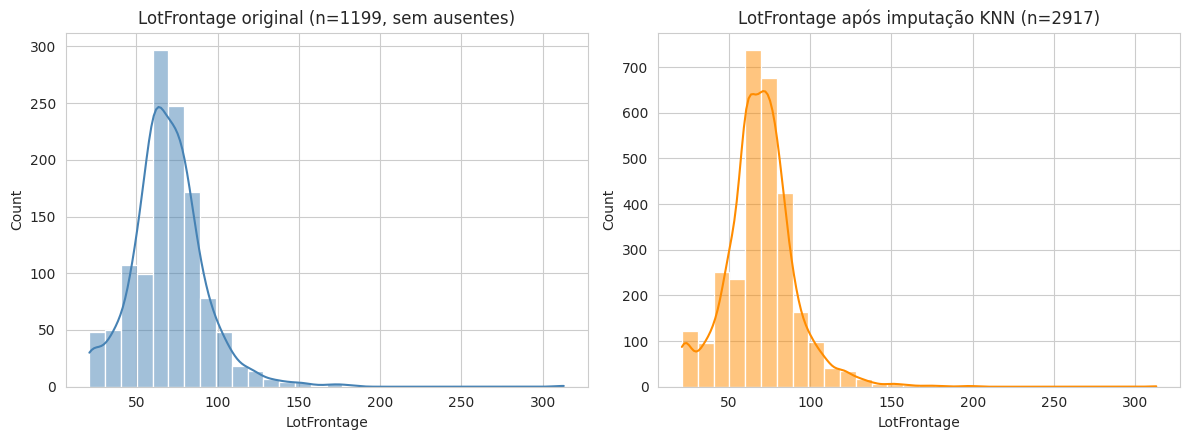

Média original : 69.80
Média pós-KNN  : 69.48


In [25]:
lot_original = train['LotFrontage'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(lot_original, kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title(f'LotFrontage original (n={len(lot_original)}, sem ausentes)')

sns.histplot(dados['LotFrontage'], kde=True, ax=axes[1], color='darkorange', bins=30)
axes[1].set_title(f'LotFrontage após imputação KNN (n={len(dados)})')

plt.tight_layout()
plt.show()

print(f'Média original : {lot_original.mean():.2f}')
print(f'Média pós-KNN  : {dados["LotFrontage"].mean():.2f}')


A distribuição se mantém praticamente igual antes e depois da imputação — o resultado esperado de um KNN que busca casas parecidas (mesmo bairro, lote de tamanho semelhante) para preencher os valores ausentes, sem "achatar" a distribuição em torno de uma única média global (o que uma imputação simples faria).

## 12. Montagem do dataset final e checagens de sanidade

Convertemos as variáveis **ordinais** para seus códigos numéricos definitivos — já prontas para qualquer modelo. As variáveis **nominais** permanecem como texto: a decisão de como codificá-las (one-hot, target encoding, etc.) é mais natural de se tomar já dentro do pipeline de modelagem.

In [26]:
for coluna, mapa in mapas_ordinais.items():
    dados[coluna] = dados[coluna].map(mapa).astype(int)

print('Exemplo de variáveis ordinais já convertidas para código numérico:')
dados[list(mapas_ordinais.keys())[:6]].head()


Exemplo de variáveis ordinais já convertidas para código numérico:


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual
0,4,3,4,3,5,4
1,3,3,4,3,5,3
2,4,3,4,3,5,4
3,3,3,3,4,4,4
4,4,3,4,3,5,4


In [27]:
X_limpo = dados.iloc[:ntrain].reset_index(drop=True)
test_limpo = dados.iloc[ntrain:].reset_index(drop=True)

print('=== Checagens de sanidade ===')
print(f'Shape X_limpo    : {X_limpo.shape}')
print(f'Shape test_limpo : {test_limpo.shape}')
print(f'Shape y          : {y.shape}')
print(f'Shape test_ids   : {test_ids.shape}')

assert X_limpo.shape[0] == y.shape[0], 'X_limpo e y devem ter o mesmo número de linhas!'
assert test_limpo.shape[0] == test_ids.shape[0], 'test_limpo e test_ids devem ter o mesmo número de linhas!'
assert X_limpo.shape[1] == test_limpo.shape[1], 'X_limpo e test_limpo devem ter as mesmas colunas!'
assert X_limpo.isnull().sum().sum() == 0, 'Ainda há valores ausentes em X_limpo!'
assert test_limpo.isnull().sum().sum() == 0, 'Ainda há valores ausentes em test_limpo!'
assert (X_limpo.columns == test_limpo.columns).all(), 'As colunas de treino e teste devem estar na mesma ordem!'
assert 'Id' not in X_limpo.columns, 'Id não deveria estar entre as features!'

print('\nTodas as checagens passaram ✔')
print(f'\nColunas ordinais numéricas prontas para uso : {len(mapas_ordinais)}')
print(f'Colunas nominais (texto, a codificar depois) : {len(colunas_nominais)}')
print(f'Colunas numéricas originais                  : {len(colunas_numericas)}')


=== Checagens de sanidade ===
Shape X_limpo    : (1458, 79)
Shape test_limpo : (1459, 79)
Shape y          : (1458,)
Shape test_ids   : (1459,)

Todas as checagens passaram ✔

Colunas ordinais numéricas prontas para uso : 23
Colunas nominais (texto, a codificar depois) : 23
Colunas numéricas originais                  : 33


In [28]:
dtype_resumo = X_limpo.dtypes.astype(str).replace({'str':'object'}).value_counts()
print('Resumo de tipos em X_limpo:')
print(dtype_resumo)


Resumo de tipos em X_limpo:
int64      45
object     23
float64    11
Name: count, dtype: int64


## 13. Exportação dos dados processados

Salvamos os conjuntos processados em disco para serem consumidos diretamente pela próxima etapa (modelagem), evitando repetir todo o pré-processamento a cada novo experimento.

In [29]:
X_limpo.to_csv('X_train_processado.csv', index=False)
test_limpo.to_csv('X_test_processado.csv', index=False)
y.to_csv('y_train_log.csv', index=False)
test_ids.to_csv('test_ids.csv', index=False)

print('Arquivos salvos:')
print(' - X_train_processado.csv ', X_limpo.shape)
print(' - X_test_processado.csv  ', test_limpo.shape)
print(' - y_train_log.csv        ', y.shape, '(já em escala log1p)')
print(' - test_ids.csv           ', test_ids.shape)


Arquivos salvos:
 - X_train_processado.csv  (1458, 79)
 - X_test_processado.csv   (1459, 79)
 - y_train_log.csv         (1458,) (já em escala log1p)
 - test_ids.csv            (1459,)


## 14. Conclusão

O pré-processamento final combina rigor metodológico com transparência de execução:

1. **Remove os outliers** de `GrLivArea` e **transforma o alvo** com `log1p`, alinhado à métrica oficial e à assimetria observada na EDA.
2. **Corrige a ordem das operações**: variáveis mal-classificadas (`MSSubClass`, `MoSold`, `YrSold`) são ajustadas antes de qualquer codificação ou imputação.
3. **Identifica e corrige 5 grupos de inconsistência estrutural** (garagem, porão, revestimento de alvenaria, piscina, recurso diverso) — casos em que o dataset afirma que um recurso existe, mas parte de seus atributos está genuinamente perdida. Tratá-los como "sem o recurso" introduziria um erro factual no dataset.
4. **Distingue corretamente variáveis ordinais de nominais**, aplicando a ordem semântica correta às ordinais e evitando ordens artificiais nas nominais.
5. **Elimina o vazamento de dados**: todo transformador estatístico (`StandardScaler`, `KNNImputer`, moda) é ajustado somente no treino.
6. **Escolhe a técnica de imputação de forma proporcional ao problema**: KNN multivariado onde há volume e sinal, moda simples e transparente onde restam poucos casos isolados.
7. **Valida o resultado**, confirmando que os valores gerados são plausíveis e preservam padrões observados na EDA.

O dataset resultante (`X_train_processado.csv` / `X_test_processado.csv` / `y_train_log.csv`) está limpo, factualmente consistente, sem vazamento de dados, com todas as variáveis ordinais já codificadas — pronto para a próxima etapa: codificação final das variáveis nominais (dentro do pipeline de modelagem) e treinamento dos modelos preditivos.